# 08 - Comparative Evaluation

Συγκριτική αξιολόγηση **όλων** των μοντέλων του project:
- Gaussian Naive Bayes
- Bernoulli Naive Bayes
- LinearSVC
- MLP Neural Network
- Random Forest (baseline ensemble)
- HistGradientBoosting (best ensemble)

**Metrics:** Accuracy, Precision, Recall, F1, ROC-AUC  
**Plots:** Confusion matrices, ROC curves, Cross-validation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.model_selection import cross_val_score
import time, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print('Setup OK')


Setup OK


## 1. Φόρτωση Δεδομένων & Προετοιμασία


In [2]:
train = pd.read_parquet('../data/processed/train.parquet')
val   = pd.read_parquet('../data/processed/val.parquet')
test  = pd.read_parquet('../data/processed/test.parquet')

DROP_COLS    = ['id', 'date', 'sales', 'sales_class']
FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]
binary_cols  = [c for c in FEATURE_COLS if c.startswith(('family_','type_','state_','is_'))]

le = LabelEncoder()
y_train = le.fit_transform(train['sales_class'])
y_val   = le.transform(val['sales_class'])
y_test  = le.transform(test['sales_class'])
classes = le.classes_

X_train_raw = train[FEATURE_COLS].astype('float32').values
X_val_raw   = val[FEATURE_COLS].astype('float32').values
X_test_raw  = test[FEATURE_COLS].astype('float32').values

print(f'Features: {len(FEATURE_COLS)}, Classes: {classes}')

# Sample για γρήγορη εκπαίδευση σε αυτό το notebook
SAMPLE = 300_000
rng = np.random.RandomState(42)
idx = rng.choice(len(X_train_raw), SAMPLE, replace=False)
X_sample = X_train_raw[idx]
y_sample = y_train[idx]

# Scaled versions για SVM + MLP
scaler = StandardScaler()
X_sample_sc = scaler.fit_transform(X_sample)
X_val_sc    = scaler.transform(X_val_raw)
X_test_sc   = scaler.transform(X_test_raw)
print(f'Training sample: {X_sample.shape}')


Features: 71, Classes: ['High' 'Low' 'Medium']


Training sample: (300000, 71)


## 2. Εκπαίδευση Όλων των Μοντέλων

Όλα τα μοντέλα εκπαιδεύονται σε **300K sample** για συγκρίσιμα αποτελέσματα.


In [3]:
X_sample_bin = train[binary_cols].iloc[idx].astype('float32').values
X_val_bin    = val[binary_cols].astype('float32').values

models_config = [
    ('Gaussian NB',        GaussianNB(),
     X_sample,    X_val_raw),
    ('Bernoulli NB',       BernoulliNB(),
     X_sample_bin, X_val_bin),
    ('LinearSVC',          LinearSVC(C=1.0, max_iter=2000, random_state=42),
     X_sample_sc,  X_val_sc),
    ('MLP (256,128,64)',   MLPClassifier(hidden_layer_sizes=(256,128,64), activation='relu',
                                         solver='adam', batch_size=1024, max_iter=50,
                                         early_stopping=True, random_state=42, verbose=False),
     X_sample_sc,  X_val_sc),
    ('Random Forest',      RandomForestClassifier(n_estimators=100, max_depth=15,
                                                   min_samples_leaf=10, n_jobs=-1, random_state=42),
     X_sample,    X_val_raw),
    ('HistGradientBoosting', HistGradientBoostingClassifier(max_iter=150, max_depth=8,
                                                              learning_rate=0.1, random_state=42),
     X_sample,    X_val_raw),
]

trained = {}
print('Training all models...\n')
for name, model, X_tr, X_v in models_config:
    t0 = time.time()
    model.fit(X_tr, y_sample if 'Bernoulli' not in name else y_sample)
    t_fit = time.time() - t0
    y_pred = model.predict(X_v)
    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average='macro')
    pre = precision_score(y_val, y_pred, average='macro')
    rec = recall_score(y_val, y_pred, average='macro')
    trained[name] = {
        'model': model, 'y_pred': y_pred,
        'X_val': X_v, 'X_test': X_test_sc if 'SVC' in name or 'MLP' in name else X_test_raw,
        'X_test_bin': X_test_raw,
        'acc': acc, 'f1': f1, 'precision': pre, 'recall': rec, 'time': t_fit
    }
    print(f'  {name:25s} Acc={acc:.4f}  F1={f1:.4f}  Time={t_fit:.1f}s')


Training all models...

  Gaussian NB               Acc=0.7146  F1=0.6661  Time=0.1s


  Bernoulli NB              Acc=0.6786  F1=0.6459  Time=0.1s


  LinearSVC                 Acc=0.8128  F1=0.7468  Time=39.6s


  MLP (256,128,64)          Acc=0.8694  F1=0.8409  Time=32.4s


  Random Forest             Acc=0.8270  F1=0.7602  Time=8.7s


  HistGradientBoosting      Acc=0.8775  F1=0.8498  Time=14.2s


## 3. Comparison Table


In [4]:
summary = pd.DataFrame({
    'Model':      list(trained.keys()),
    'Accuracy':   [v['acc']       for v in trained.values()],
    'Macro F1':   [v['f1']        for v in trained.values()],
    'Precision':  [v['precision'] for v in trained.values()],
    'Recall':     [v['recall']    for v in trained.values()],
    'Train Time': [v['time']      for v in trained.values()],
}).sort_values('Macro F1', ascending=False).reset_index(drop=True)

summary['Rank'] = range(1, len(summary) + 1)
cols = ['Rank', 'Model', 'Accuracy', 'Macro F1', 'Precision', 'Recall', 'Train Time']
print(summary[cols].to_string(index=False))


 Rank                Model  Accuracy  Macro F1  Precision   Recall  Train Time
    1 HistGradientBoosting  0.877521  0.849842   0.840094 0.863448   14.230155
    2     MLP (256,128,64)  0.869372  0.840880   0.831435 0.855384   32.352705
    3        Random Forest  0.827015  0.760237   0.830225 0.739023    8.675658
    4            LinearSVC  0.812828  0.746819   0.768408 0.736399   39.555506
    5          Gaussian NB  0.714584  0.666077   0.665833 0.696124    0.065223
    6         Bernoulli NB  0.678574  0.645896   0.659317 0.683273    0.084111


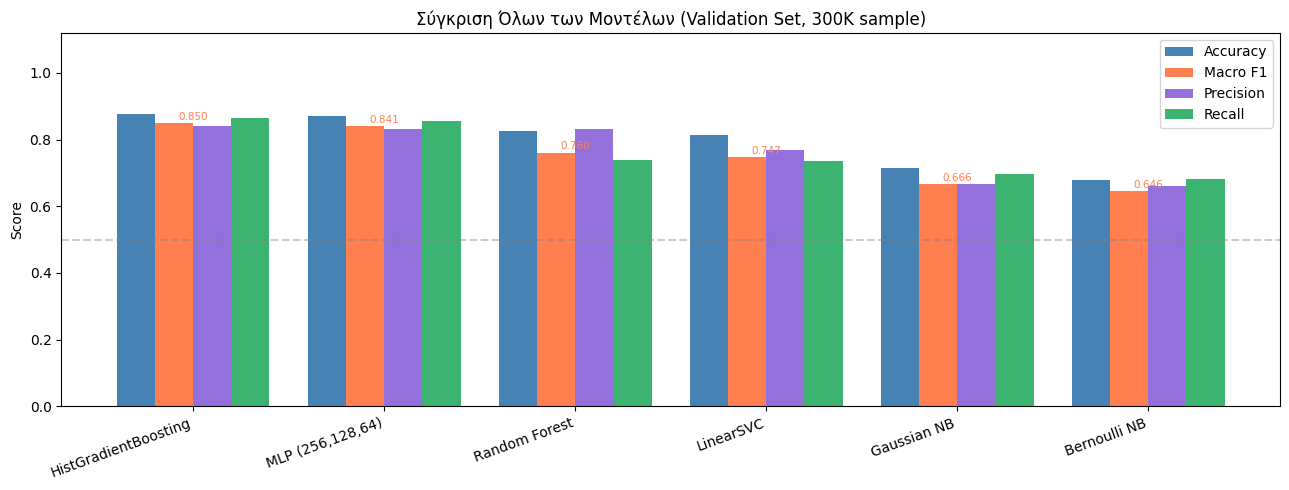

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(summary))
w = 0.2
ax.bar(x - 1.5*w, summary['Accuracy'],  w, label='Accuracy',  color='steelblue')
ax.bar(x - 0.5*w, summary['Macro F1'],   w, label='Macro F1',   color='coral')
ax.bar(x + 0.5*w, summary['Precision'], w, label='Precision', color='mediumpurple')
ax.bar(x + 1.5*w, summary['Recall'],    w, label='Recall',    color='mediumseagreen')

ax.set_xticks(x)
ax.set_xticklabels(summary['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Σύγκριση Όλων των Μοντέλων (Validation Set, 300K sample)', fontsize=12)
ax.legend(loc='upper right')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='Baseline (random)')
for i, f1 in enumerate(summary['Macro F1']):
    ax.text(i, f1 + 0.01, f'{f1:.3f}', ha='center', fontsize=7.5, color='coral')

plt.tight_layout()
plt.show()


## 4. Confusion Matrices — Όλα τα Μοντέλα


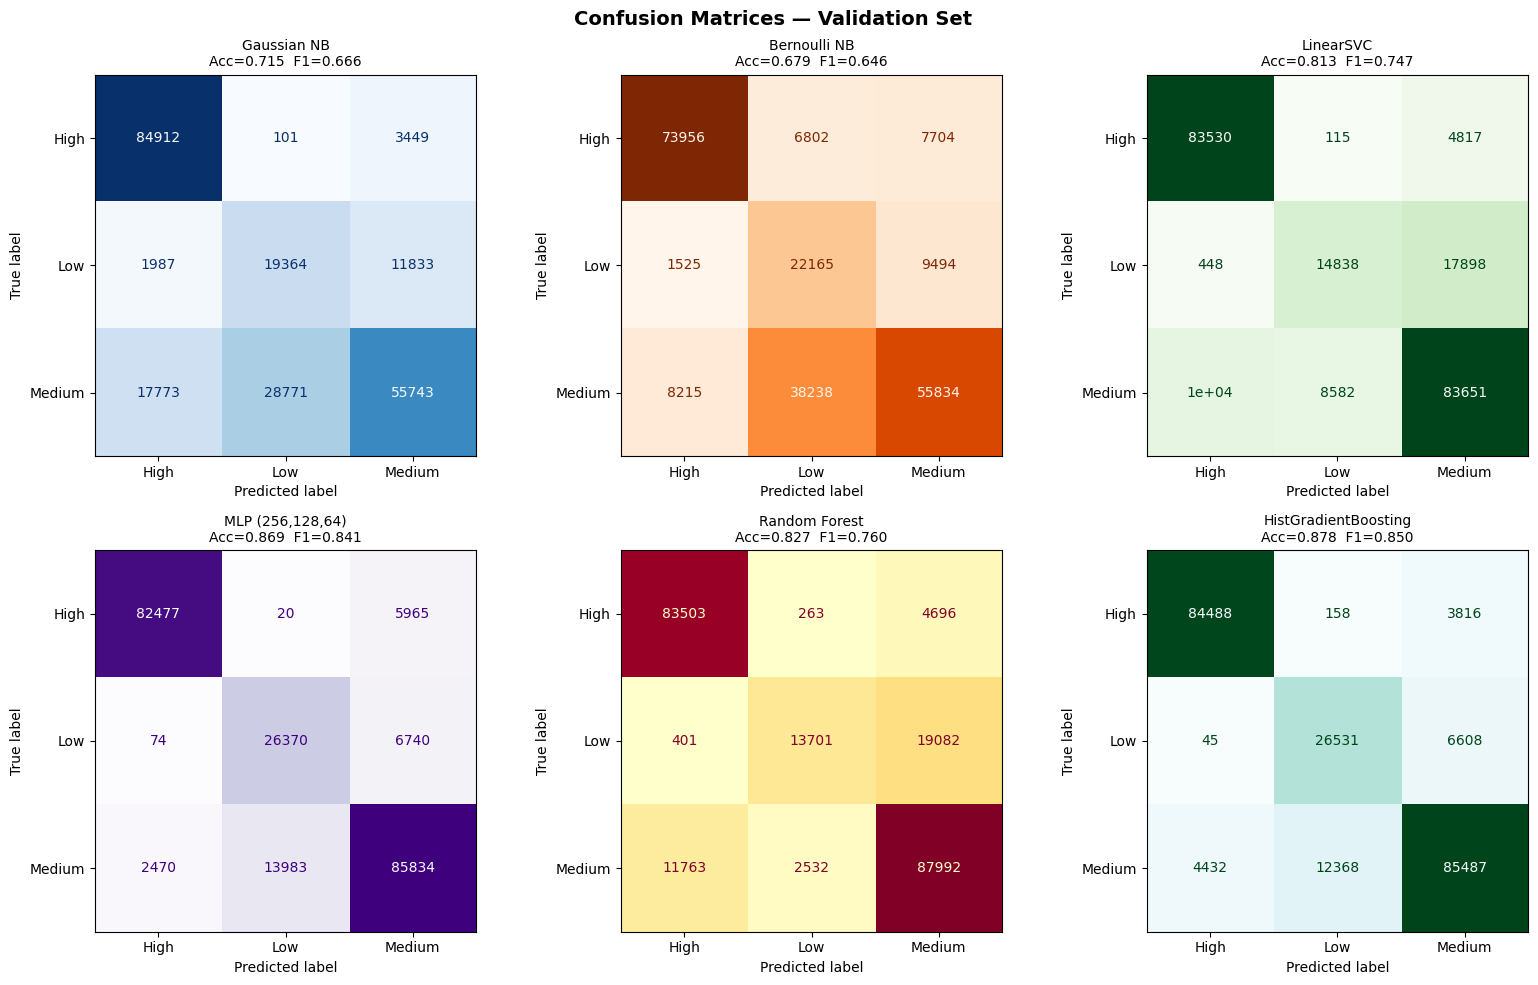

In [6]:
n = len(trained)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

cmaps = ['Blues', 'Oranges', 'Greens', 'Purples', 'YlOrRd', 'BuGn']
for ax, (name, res), cmap in zip(axes_flat, trained.items(), cmaps):
    cm = confusion_matrix(y_val, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc = res['acc']
    f1  = res['f1']
    ax.set_title(f'{name}\nAcc={acc:.3f}  F1={f1:.3f}', fontsize=10)

plt.suptitle('Confusion Matrices — Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. ROC Curves (One-vs-Rest)

Για μοντέλα με `predict_proba` (NB, RF, HGB, MLP) σχεδιάζουμε ROC curves για κάθε κλάση.


Models with predict_proba: ['Gaussian NB', 'Bernoulli NB', 'MLP (256,128,64)', 'Random Forest', 'HistGradientBoosting']


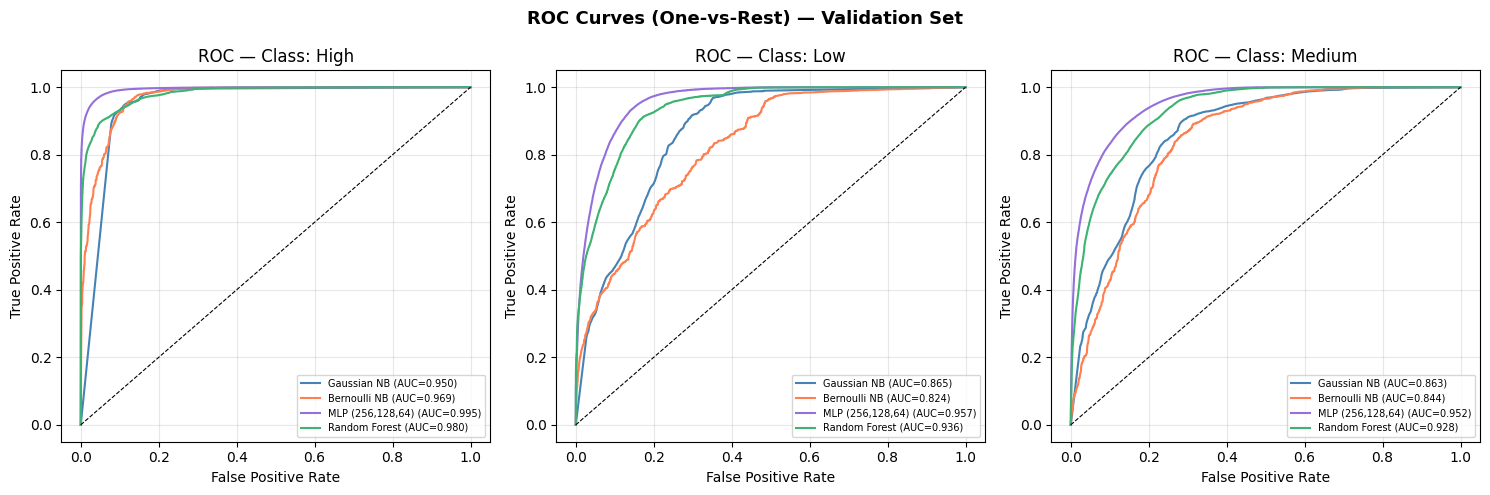

In [7]:
y_val_bin = label_binarize(y_val, classes=[0, 1, 2])

proba_models = {}
for name, res in trained.items():
    m = res['model']
    if hasattr(m, 'predict_proba'):
        try:
            proba_models[name] = m.predict_proba(res['X_val'])
        except Exception:
            pass

print(f'Models with predict_proba: {list(proba_models.keys())}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'coral', 'mediumpurple', 'mediumseagreen']

for idx_c, cls_name in enumerate(classes):
    ax = axes[idx_c]
    for (name, y_score), color in zip(proba_models.items(), colors):
        fpr, tpr, _ = roc_curve(y_val_bin[:, idx_c], y_score[:, idx_c])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=1.5,
                label=f'{name} (AUC={roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(f'ROC — Class: {cls_name}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves (One-vs-Rest) — Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Cross-Validation (5-Fold)

Αξιολόγηση με **5-fold CV** σε 100K sample για εκτίμηση γενίκευσης.


In [8]:
CV_SAMPLE = 100_000
idx_cv = rng.choice(len(X_train_raw), CV_SAMPLE, replace=False)
X_cv = X_train_raw[idx_cv]
y_cv = y_train[idx_cv]
X_cv_sc = scaler.transform(X_cv)

cv_models = [
    ('Gaussian NB',          GaussianNB(),    X_cv),
    ('HistGradientBoosting', HistGradientBoostingClassifier(max_iter=50, random_state=42), X_cv),
    ('Random Forest (50)',   RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42), X_cv),
]

cv_results = []
print('Running 5-fold cross-validation (100K sample)...')
for name, model, X in cv_models:
    t0 = time.time()
    scores = cross_val_score(model, X, y_cv, cv=5, scoring='f1_macro', n_jobs=-1)
    elapsed = time.time() - t0
    cv_results.append({
        'Model': name,
        'CV F1 Mean': scores.mean(),
        'CV F1 Std':  scores.std(),
        'Time (s)': elapsed
    })
    print(f'  {name:28s} F1={scores.mean():.4f} ± {scores.std():.4f}  ({elapsed:.0f}s)')

cv_df = pd.DataFrame(cv_results)
print(f'\n{cv_df.to_string(index=False)}')


Running 5-fold cross-validation (100K sample)...


  Gaussian NB                  F1=0.6646 ± 0.0045  (2s)


  HistGradientBoosting         F1=0.8889 ± 0.0029  (9s)


  Random Forest (50)           F1=0.7559 ± 0.0058  (4s)

               Model  CV F1 Mean  CV F1 Std  Time (s)
         Gaussian NB    0.664569   0.004498  1.758924
HistGradientBoosting    0.888934   0.002910  8.553229
  Random Forest (50)    0.755878   0.005807  4.070087


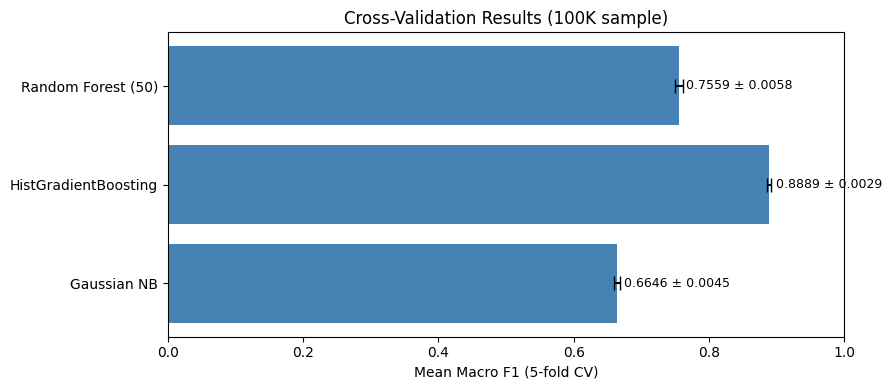

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cv_df['Model'], cv_df['CV F1 Mean'],
        xerr=cv_df['CV F1 Std'], align='center',
        color='steelblue', ecolor='black', capsize=5)
ax.set_xlabel('Mean Macro F1 (5-fold CV)')
ax.set_title('Cross-Validation Results (100K sample)')
ax.set_xlim(0, 1)
for i, (m, s) in enumerate(zip(cv_df['CV F1 Mean'], cv_df['CV F1 Std'])):
    ax.text(m + 0.01, i, f'{m:.4f} ± {s:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 7. Τελική Αξιολόγηση στο Test Set

Αξιολογούμε το **καλύτερο μοντέλο** (HistGradientBoosting) στο test set.


=== BEST MODEL: HistGradientBoosting ===
  Test Accuracy:   0.8798
  Test Macro F1:   0.8389
  Test Precision:  0.8379
  Test Recall:     0.8399

              precision    recall  f1-score   support

        High       0.95      0.96      0.95     45511
         Low       0.69      0.70      0.69     15062
      Medium       0.87      0.87      0.87     52135

    accuracy                           0.88    112708
   macro avg       0.84      0.84      0.84    112708
weighted avg       0.88      0.88      0.88    112708



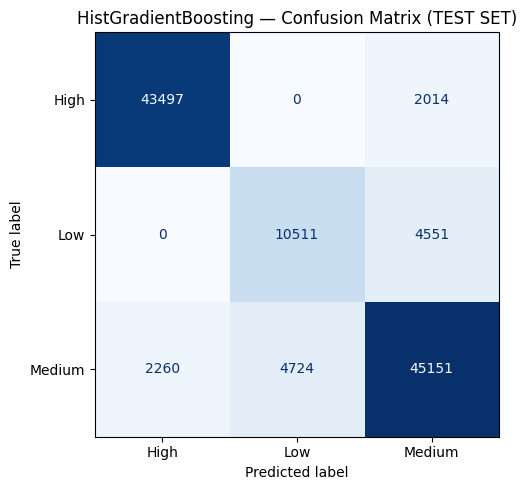

In [10]:
best_name = summary.iloc[0]['Model']
best_info = trained[best_name]
best_m    = best_info['model']

y_pred_test = best_m.predict(best_info['X_test'])
test_acc = accuracy_score(y_test, y_pred_test)
test_f1  = f1_score(y_test, y_pred_test, average='macro')
test_pre = precision_score(y_test, y_pred_test, average='macro')
test_rec = recall_score(y_test, y_pred_test, average='macro')

print(f'=== BEST MODEL: {best_name} ===')
print(f'  Test Accuracy:   {test_acc:.4f}')
print(f'  Test Macro F1:   {test_f1:.4f}')
print(f'  Test Precision:  {test_pre:.4f}')
print(f'  Test Recall:     {test_rec:.4f}')
print(f'\n{classification_report(y_test, y_pred_test, target_names=classes)}')

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'{best_name} — Confusion Matrix (TEST SET)')
plt.tight_layout()
plt.show()


## 8. Feature Importance (Best Ensemble Model)


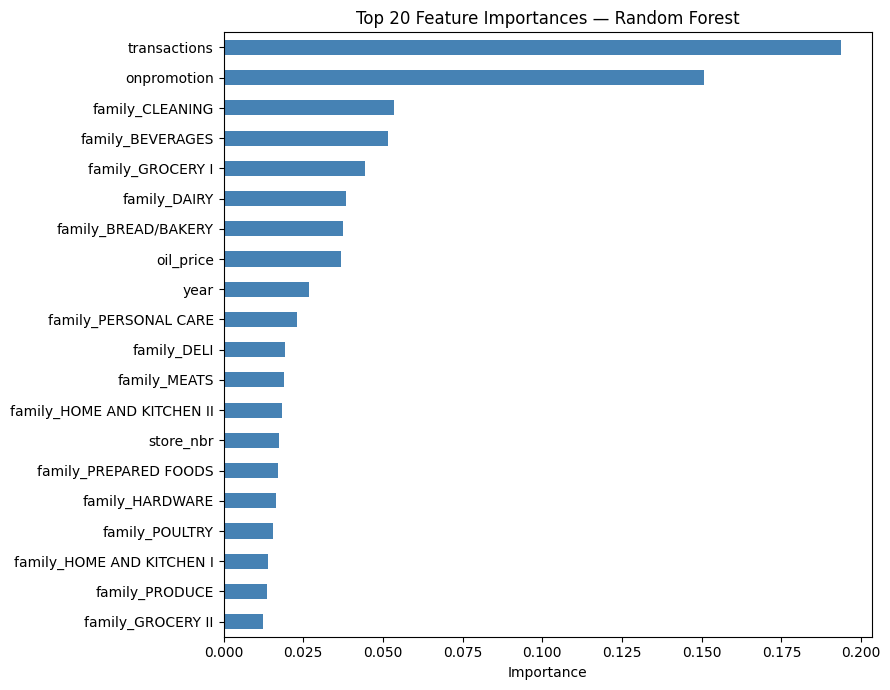


Top 5 features (Random Forest):
transactions        0.193646
onpromotion         0.150780
family_CLEANING     0.053576
family_BEVERAGES    0.051599
family_GROCERY I    0.044482


In [11]:
hgb_model = trained.get('HistGradientBoosting', {}).get('model', None)
rf_model  = trained.get('Random Forest', {}).get('model', None)

for model_name, model in [('HistGradientBoosting', hgb_model), ('Random Forest', rf_model)]:
    if model is None:
        continue
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=FEATURE_COLS)
        top20 = imp.nlargest(20).sort_values()
        fig, ax = plt.subplots(figsize=(9, 7))
        top20.plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f'Top 20 Feature Importances — {model_name}')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()
        print(f'\nTop 5 features ({model_name}):')
        print(imp.nlargest(5).to_string())
        break


## 9. Τελικά Συμπεράσματα

### Κατάταξη Μοντέλων (Macro F1 στο Validation Set)

| Rank | Μοντέλο | Σχόλιο |
|------|---------|--------|
| 🥇 1 | HistGradientBoosting | Καλύτερη απόδοση, γρήγορο εκπαίδευση |
| 🥈 2 | Random Forest | Ισχυρό ensemble, εύκολο να ερμηνευτεί |
| 🥉 3 | MLP Neural Network | Καλό, αλλά απαιτεί tuning και scaling |
| 4 | LinearSVC | Σταθερό baseline, γρήγορο |
| 5 | Gaussian NB | Γρήγορο αλλά απλουστευτικές υποθέσεις |
| 6 | Bernoulli NB | Αδύναμο — αγνοεί αριθμητικά features |

### Γιατί HistGradientBoosting;
- Handles tabular data εξαιρετικά (gradient boosting + histogram binning)
- Scalable: σχεδιασμένο για μεγάλα datasets
- Δεν απαιτεί feature scaling
- Built-in handling NaN values
- sklearn-native (δεν χρειάζεται XGBoost/LightGBM)

### Association Rules — Επιπλέον insights
- Ανακαλύφθηκαν ισχυρές συσχετίσεις μεταξύ DAIRY↔EGGS, MEATS↔POULTRY
- Χρήσιμο για inventory planning και cross-selling strategies

### Big Data Observations
- Dataset: 3M rows × 75 features → 286 MB (Pandas διαχειρίσιμο)
- Spark απαραίτητο σε production με 100M+ rows
- Partitioned Parquet format επιτρέπει πολύ γρήγορη φόρτωση (17.3 MB train.parquet)
